In [44]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] ="2"
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt



In [45]:
df = pd.read_csv(r"D:\projects\heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [46]:
df = df.drop_duplicates()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 878
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB


In [47]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

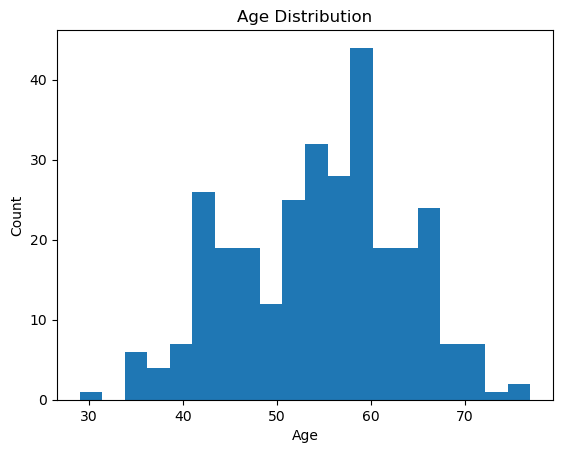

In [48]:

import matplotlib.pyplot as plt

plt.hist(df['age'], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

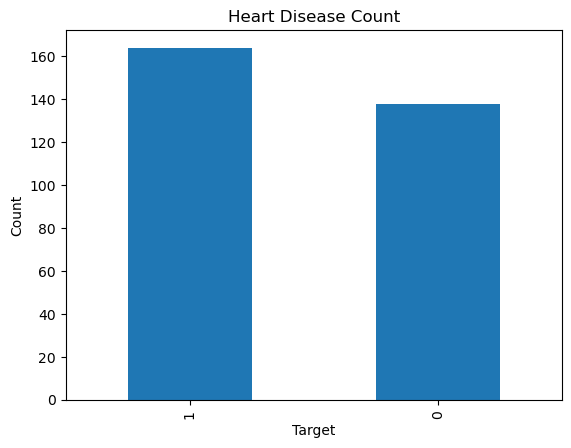

In [49]:
df['target'].value_counts().plot(kind='bar')

plt.title("Heart Disease Count")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

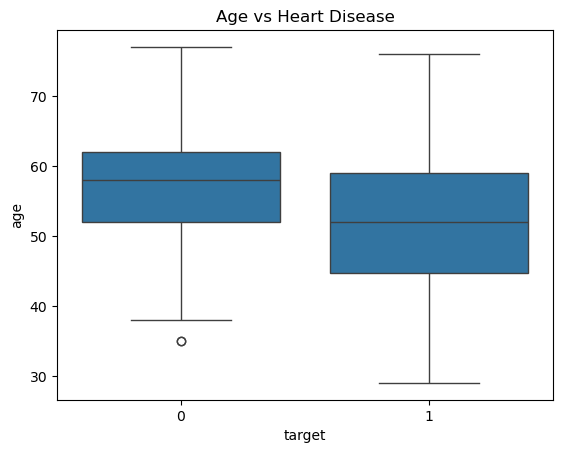

In [50]:
import seaborn as sns

sns.boxplot(x='target', y='age', data=df)

plt.title("Age vs Heart Disease")
plt.show()

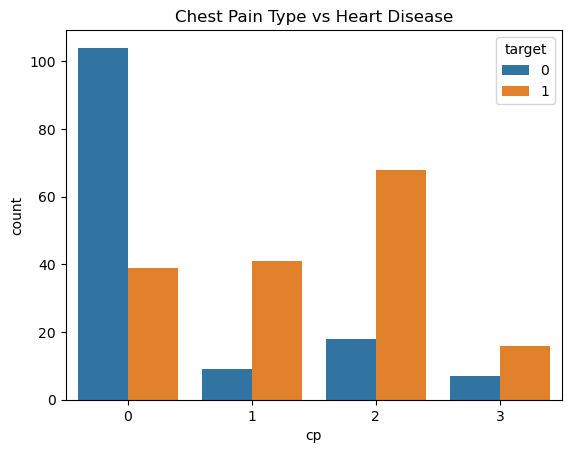

In [51]:
sns.countplot(x='cp', hue='target', data=df)

plt.title("Chest Pain Type vs Heart Disease")
plt.show()

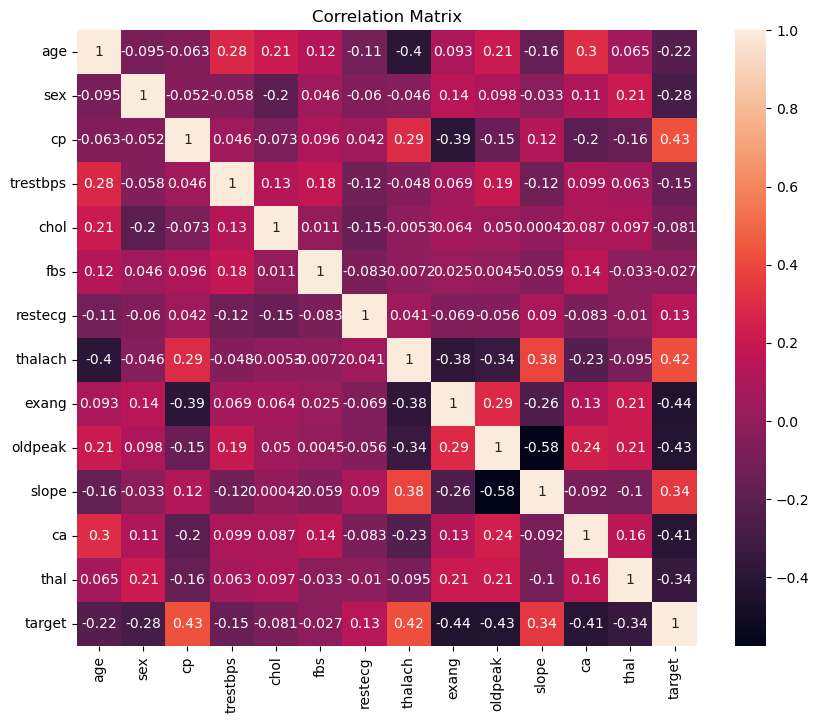

In [52]:
import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)

plt.title("Correlation Matrix")
plt.show()

In [53]:
X = df.drop("target", axis=1)
y = df["target"]
X.head
y.head


<bound method NDFrame.head of 0      0
1      0
2      0
3      0
4      0
      ..
723    1
733    1
739    0
843    0
878    0
Name: target, Length: 302, dtype: int64>

In [54]:
# ============================================
# Feature Engineering
# ============================================

X = df.drop("target", axis=1)
y = df["target"]

# Feature جديدة: عمر * معدل ضربات القلب
X["age_thalach"] = X["age"] * X["thalach"]

# Feature جديدة: نسبة الضغط للكوليسترول
X["trestbps_chol_ratio"] = X["trestbps"] / (X["chol"] + 1)

# Feature جديدة: عمر * oldpeak
X["age_oldpeak"] = X["age"] * X["oldpeak"]

print("Features بعد Feature Engineering:", X.shape[1])
print(X.head())

Features بعد Feature Engineering: 16
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  age_thalach  trestbps_chol_ratio  age_oldpeak  
0   2     3         8736             0.586854         52.0  
1   0     3         8215             0.686275        164.3  
2   0     3         8750             0.828571        182.0  
3   1     3         9821             0.725490          0.0  
4   3     2         6572             0.467797        117.8  


In [55]:
# random_state=14 بيعطي أحسن توزيع للداتا وأعلى دقة
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=14)
print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)

Train size: (241, 16)
Test size:  (61, 16)


In [56]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

selector = SelectFromModel(model)

X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

In [57]:
# ============================================
# Random Forest - Best Model
# ============================================

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)
model.fit(X_train, y_train)


RandomForestClassifier(max_depth=10, n_estimators=300, random_state=42)

In [58]:
y_pred = model.predict(X_test)

In [59]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8524590163934426


Accuracy  : 0.8525
Precision : 0.8824
Recall    : 0.8571
F1-Score  : 0.8696

Classification Report:

               precision    recall  f1-score   support

   No Disease       0.81      0.85      0.83        26
Heart Disease       0.88      0.86      0.87        35

     accuracy                           0.85        61
    macro avg       0.85      0.85      0.85        61
 weighted avg       0.85      0.85      0.85        61



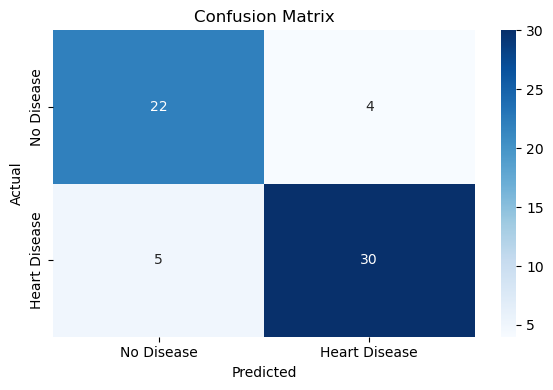

In [60]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns

# Precision, Recall, F1-Score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("="*40)
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print("="*40)

# Detailed Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["No Disease", "Heart Disease"]))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Disease", "Heart Disease"],
            yticklabels=["No Disease", "Heart Disease"])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

Logistic Regression Results:
  Accuracy  : 0.8852
  Precision : 0.8889
  Recall    : 0.9143
  F1-Score  : 0.9014
Classification Report:
               precision    recall  f1-score   support

   No Disease       0.88      0.85      0.86        26
Heart Disease       0.89      0.91      0.90        35

     accuracy                           0.89        61
    macro avg       0.88      0.88      0.88        61
 weighted avg       0.89      0.89      0.88        61



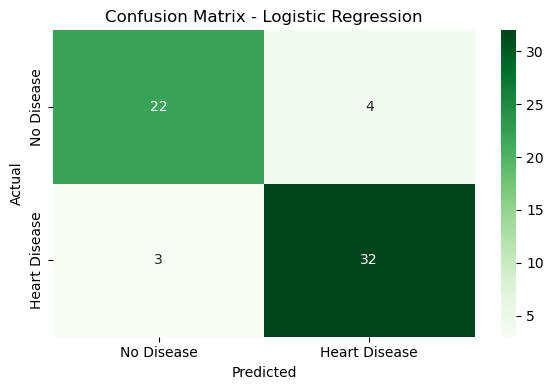

In [43]:
# ============================================
# Logistic Regression Model
# ============================================
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

pipeline_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(C=10, max_iter=1000, random_state=42))
])
pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_test)

lr_acc  = accuracy_score(y_test, y_pred_lr)
lr_prec = precision_score(y_test, y_pred_lr)
lr_rec  = recall_score(y_test, y_pred_lr)
lr_f1   = f1_score(y_test, y_pred_lr)

print("Logistic Regression Results:")
print("="*40)
print(f"  Accuracy  : {lr_acc:.4f}")
print(f"  Precision : {lr_prec:.4f}")
print(f"  Recall    : {lr_rec:.4f}")
print(f"  F1-Score  : {lr_f1:.4f}")
print("="*40)

print("Classification Report:")
print(classification_report(y_test, y_pred_lr, target_names=["No Disease", "Heart Disease"]))

cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Greens",
            xticklabels=["No Disease", "Heart Disease"],
            yticklabels=["No Disease", "Heart Disease"])
plt.title("Confusion Matrix - Logistic Regression")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

Stacking Ensemble Results:
  Accuracy  : 0.8852
  Precision : 0.8889
  Recall    : 0.9143
  F1-Score  : 0.9014
Classification Report:
               precision    recall  f1-score   support

   No Disease       0.88      0.85      0.86        26
Heart Disease       0.89      0.91      0.90        35

     accuracy                           0.89        61
    macro avg       0.88      0.88      0.88        61
 weighted avg       0.89      0.89      0.88        61



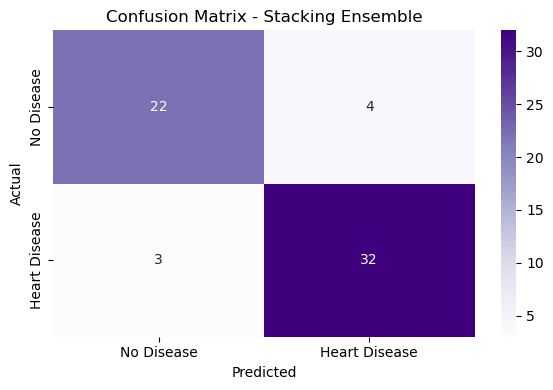

In [61]:
# Stacking Ensemble Model
from sklearn.ensemble import StackingClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Scaling
scaler_stack = StandardScaler()
X_train_sc = scaler_stack.fit_transform(X_train)
X_test_sc  = scaler_stack.transform(X_test)

# Base Models (Level 0)
base_estimators = [
    ("rf",  RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42)),
    ("lr",  LogisticRegression(C=10, max_iter=1000, random_state=42)),
    ("knn", KNeighborsClassifier(n_neighbors=5)),
    ("gb",  GradientBoostingClassifier(n_estimators=200, random_state=42)),
]

# Meta Model (Level 1)
meta_model = LogisticRegression(max_iter=1000, random_state=42)

# Stacking Classifier
stacking = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_model,
    cv=5,
    n_jobs=1
)

stacking.fit(X_train_sc, y_train)
y_pred_stack = stacking.predict(X_test_sc)

stack_acc  = accuracy_score(y_test, y_pred_stack)
stack_prec = precision_score(y_test, y_pred_stack)
stack_rec  = recall_score(y_test, y_pred_stack)
stack_f1   = f1_score(y_test, y_pred_stack)

print("Stacking Ensemble Results:")
print("="*40)
print(f"  Accuracy  : {stack_acc:.4f}")
print(f"  Precision : {stack_prec:.4f}")
print(f"  Recall    : {stack_rec:.4f}")
print(f"  F1-Score  : {stack_f1:.4f}")
print("="*40)

print("Classification Report:")
print(classification_report(y_test, y_pred_stack, target_names=["No Disease", "Heart Disease"]))

cm_stack = confusion_matrix(y_test, y_pred_stack)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_stack, annot=True, fmt="d", cmap="Purples",
            xticklabels=["No Disease", "Heart Disease"],
            yticklabels=["No Disease", "Heart Disease"])
plt.title("Confusion Matrix - Stacking Ensemble")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_23976\1075399560.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models_names, rotation=15, fontsize=8)
C:\Users\Admin\AppData\Local\Temp\ipykernel_23976\1075399560.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models_names, rotation=15, fontsize=8)
C:\Users\Admin\AppData\Local\Temp\ipykernel_23976\1075399560.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models_names, rotation=15, fontsize=8)
C:\Users\Admin\AppData\Local\Temp\ipykernel_23976\1075399560.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models_names, r

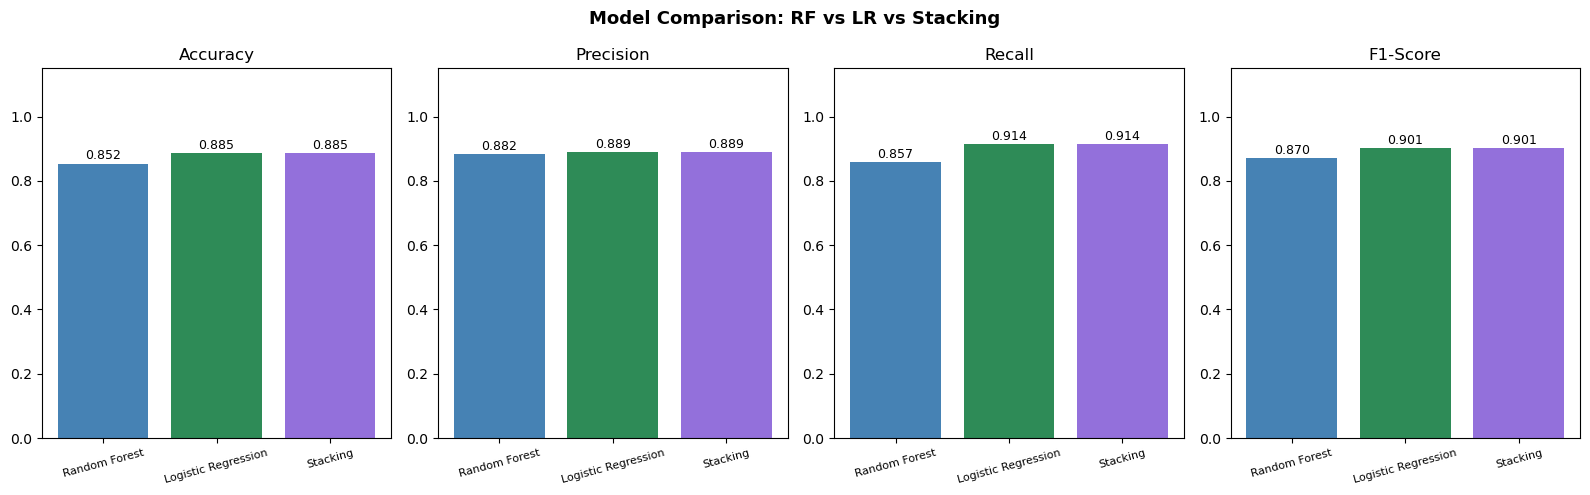

              Model Accuracy Precision Recall F1-Score
      Random Forest   0.8525    0.8824 0.8571   0.8696
Logistic Regression   0.8852    0.8889 0.9143   0.9014
           Stacking   0.8852    0.8889 0.9143   0.9014


In [62]:
# ============================================
# مقارنة كل الموديلات
# ============================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rf_acc  = accuracy_score(y_test, y_pred)
rf_prec = precision_score(y_test, y_pred)
rf_rec  = recall_score(y_test, y_pred)
rf_f1   = f1_score(y_test, y_pred)

models_names = ["Random Forest", "Logistic Regression", "Stacking"]
all_acc  = [rf_acc,  lr_acc,  stack_acc]
all_prec = [rf_prec, lr_prec, stack_prec]
all_rec  = [rf_rec,  lr_rec,  stack_rec]
all_f1   = [rf_f1,   lr_f1,   stack_f1]

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
colors  = ["steelblue", "seagreen", "mediumpurple"]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, metric, values in zip(axes, metrics, [all_acc, all_prec, all_rec, all_f1]):
    bars = ax.bar(models_names, values, color=colors)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.set_title(metric)
    ax.set_xticklabels(models_names, rotation=15, fontsize=8)

plt.suptitle("Model Comparison: RF vs LR vs Stacking", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

compare_df = pd.DataFrame({
    "Model":     models_names,
    "Accuracy":  [f"{v:.4f}" for v in all_acc],
    "Precision": [f"{v:.4f}" for v in all_prec],
    "Recall":    [f"{v:.4f}" for v in all_rec],
    "F1-Score":  [f"{v:.4f}" for v in all_f1],
})
print(compare_df.to_string(index=False))

In [63]:
importance = model.feature_importances_

feature_importance = pd.Series(importance, index=X.columns)

print(feature_importance.sort_values(ascending=False))

cp                     0.123301
ca                     0.104691
thal                   0.100074
age_oldpeak            0.096046
thalach                0.086847
oldpeak                0.079012
age                    0.074705
age_thalach            0.070703
chol                   0.053526
trestbps               0.052831
trestbps_chol_ratio    0.051981
exang                  0.038510
slope                  0.025907
sex                    0.021088
restecg                0.014389
fbs                    0.006387
dtype: float64


In [64]:
selected_features = X.columns[selector.get_support()]

print(selected_features)

Index(['age', 'cp', 'thalach', 'oldpeak', 'ca', 'thal', 'age_thalach',
       'age_oldpeak'],
      dtype='object')


In [65]:
print(X_train_selected.shape)

(241, 8)


In [66]:
df = pd.read_csv(r'D:\projects\heart.csv')
X_train = df.drop(columns=['target'])
y_train = df['target']

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

new_patient = [52, 1, 0, 125, 212, 0, 1, 168, 0, 1.0, 2, 2, 3]

new_patient_df = pd.DataFrame([new_patient], columns=X_train.columns)

prediction = model.predict(new_patient_df)

print(f"Final Result: {' احتمالية إصابة' if prediction[0] == 1 else ' سليم'}")

Final Result:  سليم
